# Investigating the influence of heat waves on work-related accident rates in Louisiana

## Importing Necessities

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import statsmodels.api as sm
import statsmodels.formula.api as smf
import patsy

from statsmodels.discrete.discrete_model import NegativeBinomial
from sklearn.metrics import mean_absolute_error, mean_squared_error

## Loading the datasets

In [2]:
PROJECT_ROOT = Path.cwd().parent
DATA_FINAL = PROJECT_ROOT / "data" / "final"

weather_file = DATA_FINAL / "lcd_analysis_2015_2025_daily_filled.csv"
accident_counts_file = DATA_FINAL / "daily_accident_counts_by_parish.csv"
threshold_file = DATA_FINAL / "parish_baseline_apparent_temp_thresholds.csv"
accident_detail_file = DATA_FINAL / "LouisianaAccidentData_with_parish.csv"
model_file = DATA_FINAL / "parish_day_modeling_dataset.csv"

In [3]:
weather = pd.read_csv(weather_file)
accident_counts = pd.read_csv(accident_counts_file)
thresholds = pd.read_csv(threshold_file)
accident_detail = pd.read_csv(accident_detail_file)
model_df = pd.read_csv(model_file)

weather["date"] = pd.to_datetime(weather["date"], errors="coerce")
accident_counts["date"] = pd.to_datetime(accident_counts["date"], errors="coerce")

print("weather:", weather.shape)
print("accident_counts:", accident_counts.shape)
print("thresholds:", thresholds.shape)
print("accident_detail:", accident_detail.shape)
print("model:", model_df.shape)

weather: (240739, 24)
accident_counts: (2290, 3)
thresholds: (64, 2)
accident_detail: (2319, 30)
model: (240739, 31)


## Analyzing The Accident Dataset

In [4]:
print(accident_detail.shape)
accident_detail.head()

(2319, 30)


,ID,UPA,EventDate,Employer,Address1,Address2,city,state,Zip,Latitude,...,Part_of_Body_Title,Event,EventTitle,Source,sourceTitle,Secondary_Source,Secondary_Source_Title,parish,naics_2digit,industry_type
0,2023065293,2042673,2023-06-15,"Waskey Bridges, Inc.",2651 N. Flannery Rd,NaN,BATON ROUGE,LOUISIANA,70814,30.47,...,"Leg(s), unspecified",6230,"Struck by falling object or equipment, unspeci...",659.0,"Structural elements, n.e.c.",NaN,NaN,East Baton Rouge,32,Manufacturing
1,2023065355,2043245,2023-06-17,"Danos, LLC",South Marsh Island 99A,NaN,HOUMA,LOUISIANA,70360,29.63,...,Fingertip(s),640,Caught in or compressed by equipment or object...,30.0,"Machinery, unspecified",NaN,NaN,Terrebonne,21,"Mining, Quarrying, and Oil and Gas Extraction"
2,2023065424,2043932,2023-06-19,"Entergy, Louisiana",1001 Virgil Street,NaN,GRETNA,LOUISIANA,70053,29.92,...,BODY SYSTEMS,531,Exposure to environmental heat,9262.0,Heat-environmental,NaN,NaN,Jefferson,22,Utilities
3,2023065435,2044277,2023-06-20,Thompson Industrial Services LLC,1202 HWY 509,NaN,MANSFIELD,LOUISIANA,71052,32.13,...,BODY SYSTEMS,531,Exposure to environmental heat,9262.0,Heat-environmental,610.0,"Confined spaces, unspecified",De Soto,42,Wholesale Trade
4,2023065457,2044220,2023-06-20,Sam's Club,10444 North Mall Drive,NaN,BATON ROUGE,LOUISIANA,70809,30.37,...,Nonclassifiable,1111,Shooting by other person-intentional,5720.0,Co-worker or work associate of injured or ill ...,7810.0,"Firearm, unspecified",East Baton Rouge,45,Retail Trade


### Accident Counts by Industry

In [5]:
industry_summary = (
    accident_detail.groupby("industry_type")
    .size()
    .reset_index(name="accident_count")
    .sort_values("accident_count", ascending=False)
)

industry_summary

,industry_type,accident_count
9,Manufacturing,634
4,Construction,441
16,Transportation and Warehousing,215
15,Retail Trade,160
19,Wholesale Trade,158
10,"Mining, Quarrying, and Oil and Gas Extraction",150
1,Administrative and Support and Waste Managemen...,145
7,Health Care and Social Assistance,66
11,Other Services (except Public Administration),59
12,"Professional, Scientific, and Technical Services",56


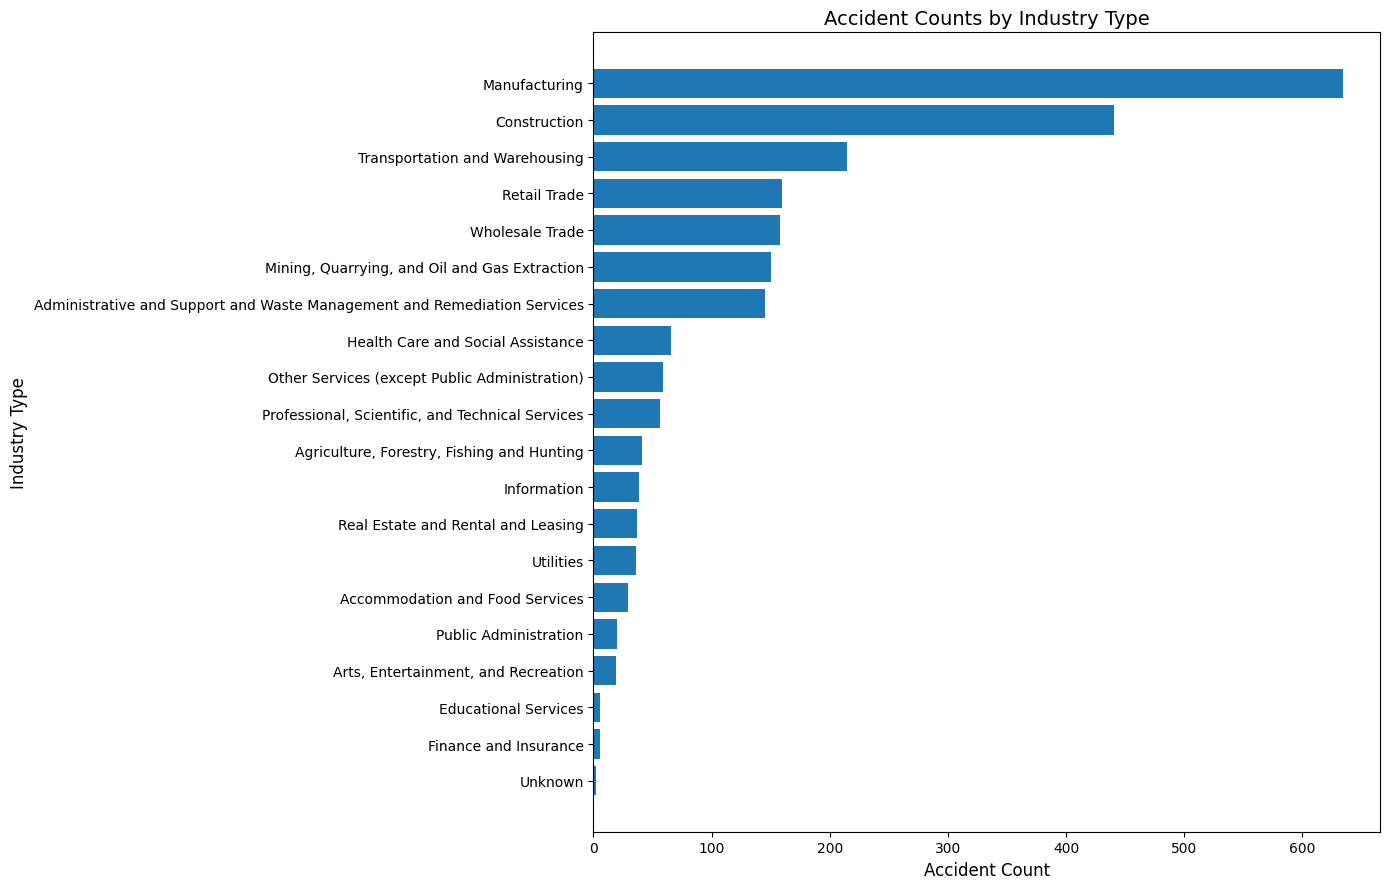

In [6]:
industry_summary_sorted = industry_summary.sort_values("accident_count", ascending=True)

plt.figure(figsize=(14, 9))
plt.barh(industry_summary_sorted["industry_type"], industry_summary_sorted["accident_count"])
plt.xlabel("Accident Count", fontsize=12)
plt.ylabel("Industry Type", fontsize=12)
plt.title("Accident Counts by Industry Type", fontsize=14)
plt.tight_layout()
plt.show()

#### The manufacturing industries face the highest accidents compared to other industry types, followed by construction. Whereas, the Finance and Insurance industries have the least accidents, followed by Educational Services

### Accident Counts by Parish

In [7]:
parish_summary = (
    accident_detail.groupby("parish")
    .size()
    .reset_index(name="accident_count")
    .sort_values("accident_count", ascending=False)
)

parish_summary

,parish,accident_count
16,East Baton Rouge,215
25,Jefferson,174
35,Orleans,161
8,Caddo,133
9,Calcasieu,126
...,...,...
17,East Carroll,3
32,Madison,3
10,Caldwell,2
45,St. Helena,2


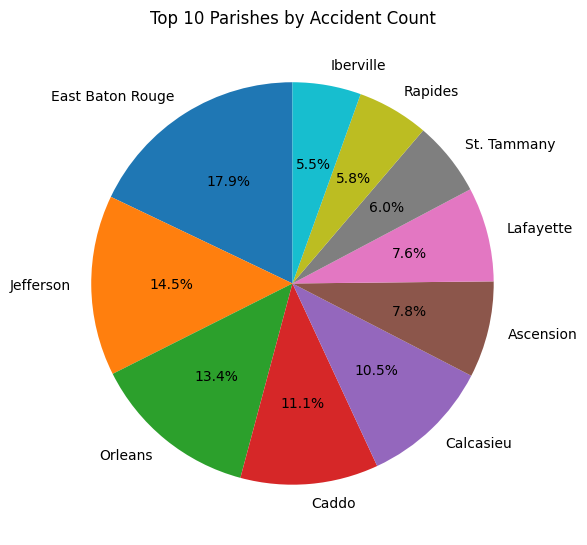

In [8]:
top_parishes = parish_summary.head(10)

plt.figure(figsize=(6, 6))
plt.pie(
    top_parishes["accident_count"],
    labels=top_parishes["parish"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Top 10 Parishes by Accident Count")
plt.tight_layout()
plt.show()

#### Most accidents were reported in the East Baton Rouge area, followed by Jefferson. The Parishes, East Baton Rouge (17.9%), Jefferson (14.5%), Orleans (13.4%) and Caddo (11.1%), together make up for more than half of the total accidents

### Accident Counts by Industry and Parish

In [9]:
industry_parish_summary = (
    accident_detail.groupby(["parish", "industry_type"])
    .size()
    .reset_index(name="accident_count")
    .sort_values("accident_count", ascending=False)
)

industry_parish_summary.head(20)

,parish,industry_type,accident_count
121,East Baton Rouge,Manufacturing,53
117,East Baton Rouge,Construction,49
66,Caddo,Manufacturing,44
78,Calcasieu,Construction,40
182,Jefferson,Construction,38
266,Orleans,Construction,36
186,Jefferson,Manufacturing,35
79,Calcasieu,Manufacturing,27
18,Ascension,Manufacturing,25
311,Rapides,Manufacturing,25


#### We can observe from the table that the work-related injuries are not evenly distributed across Louisiana, but are concentrated in a small number of parish-industry combinations. Overall, East Baton Rouge stands out most clearly, with both Manufacturing and Construction recording the highest accidents counts, suggesting a particularly strong concentration of risk-producing industrial activity there. However, manufacturing also appears repeatedly among the top entries across multiple parishes (Caddo, Jefferson, Ascension etc.). This indicates that it is one of the most consistently high-burden sectors statewide.

In [10]:
industry_parish_pivot = industry_parish_summary.pivot(
    index="parish",
    columns="industry_type",
    values="accident_count"
).fillna(0)

industry_parish_pivot.head()

industry_type,Accommodation and Food Services,Administrative and Support and Waste Management and Remediation Services,"Agriculture, Forestry, Fishing and Hunting","Arts, Entertainment, and Recreation",Construction,Educational Services,Finance and Insurance,Health Care and Social Assistance,Information,Manufacturing,"Mining, Quarrying, and Oil and Gas Extraction",Other Services (except Public Administration),"Professional, Scientific, and Technical Services",Public Administration,Real Estate and Rental and Leasing,Retail Trade,Transportation and Warehousing,Unknown,Utilities,Wholesale Trade
parish,,,,,,,,,,,,,,,,,,,,
Acadia,0.0,0.0,1.0,0.0,2.0,0.0,0.0,1.0,0.0,11.0,1.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,1.0,0.0
Allen,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,5.0,0.0,0.0,0.0,2.0,0.0,0.0,1.0,0.0,1.0,1.0
Ascension,2.0,5.0,0.0,0.0,22.0,0.0,0.0,0.0,1.0,25.0,3.0,7.0,5.0,0.0,1.0,2.0,14.0,0.0,0.0,6.0
Assumption,0.0,1.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0
Avoyelles,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,7.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


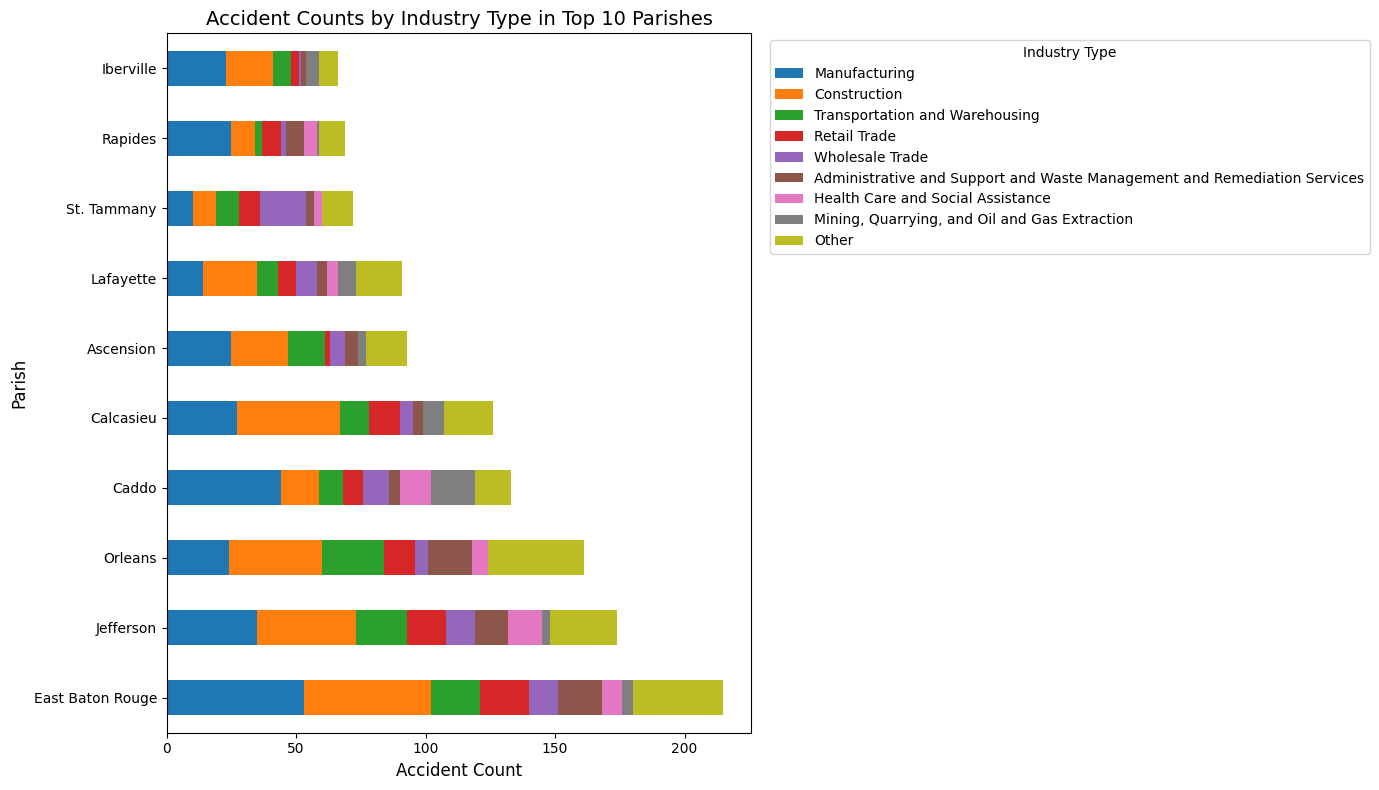

In [11]:
top_10_parishes = parish_summary.head(10)["parish"]
top_pivot = industry_parish_pivot.loc[top_10_parishes]

top_industries = top_pivot.sum().sort_values(ascending=False).head(8).index

top_pivot_clean = top_pivot[top_industries].copy()
top_pivot_clean["Other"] = top_pivot.drop(columns=top_industries).sum(axis=1)

top_pivot_clean.plot(kind="barh", stacked=True, figsize=(14, 8))

plt.xlabel("Accident Count", fontsize=12)
plt.ylabel("Parish", fontsize=12)
plt.title("Accident Counts by Industry Type in Top 10 Parishes", fontsize=14)
plt.legend(title="Industry Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

#### The accident burden is concentrated in a small set of industries within the highest-accident parishes. Manufacturing and construction account for a large share of accidents across several top parishes, while the remaining industries contribute comparatively smaller volumes. This suggests that any parish-level heat-wave analysis should also account for differences in industrial composition.

## Building the Full Merged Parish-day Dataset

#### Our accident count file only has parish-days with at least one accident. For descriptive comparison, we need all parish-days from the weather file, including days with zero accidents.

In [12]:
merged = weather.merge(
    accident_counts[["parish", "date", "accident_count"]],
    on=["parish", "date"],
    how="left"
)

merged["accident_count"] = merged["accident_count"].fillna(0).astype(int)

print("Merged shape:", merged.shape)
merged.head()

Merged shape: (240739, 25)


,parish,lcd_station_id,lcd_station_name,station_latitude,station_longitude,date,avg_temp,avg_dew_point,avg_relative_humidity,avg_wind_speed,...,avg_wind_speed_ms,vapor_pressure_hpa,avg_apparent_temp_c,min_apparent_temp_c,apparent_temp_85th_percentile,exceeds_threshold,run_id,run_length,heatwave_flag,accident_count
0,Acadia,WBAN:00381,"JENNINGS AIRPORT, LA US",30.243,-92.673,2015-01-01,6.770833,4.251389,84.444444,3.800000,...,3.800000,8.269414,2.839740,1.268907,28.893006,False,1,168,non-heat-wave,0
1,Acadia,WBAN:00381,"JENNINGS AIRPORT, LA US",30.243,-92.673,2015-01-02,13.173611,13.100000,99.472222,2.743056,...,2.743056,15.046863,12.218937,7.845326,28.893006,False,1,168,non-heat-wave,0
2,Acadia,WBAN:00381,"JENNINGS AIRPORT, LA US",30.243,-92.673,2015-01-03,16.840278,16.733333,99.305556,3.327778,...,3.327778,19.008862,16.783758,11.943480,28.893006,False,1,168,non-heat-wave,0
3,Acadia,WBAN:00381,"JENNINGS AIRPORT, LA US",30.243,-92.673,2015-01-04,8.555556,5.820833,83.666667,4.259722,...,4.259722,9.224931,4.617977,0.062422,28.893006,False,1,168,non-heat-wave,0
4,Acadia,WBAN:00381,"JENNINGS AIRPORT, LA US",30.243,-92.673,2015-01-05,3.455556,-0.893056,74.527778,3.583333,...,3.583333,5.720057,-1.165159,-4.620714,28.893006,False,1,168,non-heat-wave,0


In [13]:
print("Rows with zero accidents:", (merged["accident_count"] == 0).sum())
print("Rows with one or more accidents:", (merged["accident_count"] > 0).sum())
print("Unique parishes:", merged["parish"].nunique())
print("Date range:", merged["date"].min(), "to", merged["date"].max())

Rows with zero accidents: 238504
Rows with one or more accidents: 2235
Unique parishes: 64
Date range: 2015-01-01 00:00:00 to 2025-07-31 00:00:00


## Descriptive Statistical Analysis

### State-level Comparison

In [14]:
state_summary = (
    merged.groupby("heatwave_flag")["accident_count"]
    .agg(["mean", "std", "sum", "count"])
    .reset_index()
)

state_summary

,heatwave_flag,mean,std,sum,count
0,heat-wave,0.011171,0.105106,163,14591
1,non-heat-wave,0.009282,0.097130,2099,226148


In [15]:
non_heat_mean = state_summary.loc[
    state_summary["heatwave_flag"] == "non-heat-wave", "mean"
].iloc[0]

heat_mean = state_summary.loc[
    state_summary["heatwave_flag"] == "heat-wave", "mean"
].iloc[0]

percent_change = ((heat_mean - non_heat_mean) / non_heat_mean) * 100

print("Mean accident count on heat-wave days:", heat_mean)
print("Mean accident count on non-heat-wave days:", non_heat_mean)
print("Percent change:", percent_change)

Mean accident count on heat-wave days: 0.011171269960934822
Mean accident count on non-heat-wave days: 0.009281532447777562
Percent change: 20.36018861960401


#### This implies that there is significantly more accidents occuring during heat-wave days compared to non-heat-wave days (about 20.3% higher based on the mean values)

### Parish-level Comparison

In [16]:
parish_summary = (
    merged.groupby(["parish", "heatwave_flag"])["accident_count"]
    .agg(["mean", "std", "sum", "count"])
    .reset_index()
)

parish_summary.head(10)

,parish,heatwave_flag,mean,std,sum,count
0,Acadia,heat-wave,0.006270,0.079056,2,319
1,Acadia,non-heat-wave,0.004905,0.069872,17,3466
2,Allen,heat-wave,0.009091,0.095346,1,110
3,Allen,non-heat-wave,0.002985,0.054562,11,3685
4,Ascension,heat-wave,0.019231,0.137501,8,416
5,Ascension,non-heat-wave,0.023256,0.155804,60,2580
6,Assumption,heat-wave,0.007812,0.088215,2,256
7,Assumption,non-heat-wave,0.003138,0.055941,11,3505
8,Avoyelles,heat-wave,0.007353,0.085591,2,272
9,Avoyelles,non-heat-wave,0.003622,0.060084,13,3589


In [17]:
parish_compare = parish_summary.pivot(
    index="parish",
    columns="heatwave_flag",
    values=["mean", "std", "sum", "count"]
)

parish_compare.columns = [
    f"{stat}_{flag}" for stat, flag in parish_compare.columns
]
parish_compare = parish_compare.reset_index()

parish_compare.head()


,parish,mean_heat-wave,mean_non-heat-wave,std_heat-wave,std_non-heat-wave,sum_heat-wave,sum_non-heat-wave,count_heat-wave,count_non-heat-wave
0,Acadia,0.006270,0.004905,0.079056,0.069872,2.0,17.0,319.0,3466.0
1,Allen,0.009091,0.002985,0.095346,0.054562,1.0,11.0,110.0,3685.0
2,Ascension,0.019231,0.023256,0.137501,0.155804,8.0,60.0,416.0,2580.0
3,Assumption,0.007812,0.003138,0.088215,0.055941,2.0,11.0,256.0,3505.0
4,Avoyelles,0.007353,0.003622,0.085591,0.060084,2.0,13.0,272.0,3589.0


In [18]:
parish_compare["percent_change_mean"] = (
    (parish_compare["mean_heat-wave"] - parish_compare["mean_non-heat-wave"])
    / parish_compare["mean_non-heat-wave"]
) * 100

parish_compare.head()

,parish,mean_heat-wave,mean_non-heat-wave,std_heat-wave,std_non-heat-wave,sum_heat-wave,sum_non-heat-wave,count_heat-wave,count_non-heat-wave,percent_change_mean
0,Acadia,0.006270,0.004905,0.079056,0.069872,2.0,17.0,319.0,3466.0,27.825927
1,Allen,0.009091,0.002985,0.095346,0.054562,1.0,11.0,110.0,3685.0,204.545455
2,Ascension,0.019231,0.023256,0.137501,0.155804,8.0,60.0,416.0,2580.0,-17.307692
3,Assumption,0.007812,0.003138,0.088215,0.055941,2.0,11.0,256.0,3505.0,148.934659
4,Avoyelles,0.007353,0.003622,0.085591,0.060084,2.0,13.0,272.0,3589.0,102.997738


In [19]:
parish_compare["percent_change_mean"] = (
    (parish_compare["mean_heat-wave"] - parish_compare["mean_non-heat-wave"])
    / parish_compare["mean_non-heat-wave"]
) * 100

In [20]:
# Top 15 Parishes that witnessed higher percentage of accidents during heat-wave days on average

parish_compare.sort_values("percent_change_mean", ascending=False).head(15)

,parish,mean_heat-wave,mean_non-heat-wave,std_heat-wave,std_non-heat-wave,sum_heat-wave,sum_non-heat-wave,count_heat-wave,count_non-heat-wave,percent_change_mean
10,Caldwell,0.004386,0.000275,0.066227,0.016582,1.0,1.0,228.0,3637.0,1495.175439
38,Pointe Coupee,0.013986,0.001945,0.117845,0.044065,2.0,7.0,143.0,3599.0,619.080919
13,Claiborne,0.004016,0.000845,0.063372,0.029062,1.0,3.0,249.0,3550.0,375.234270
48,St. Landry,0.025974,0.007503,0.160101,0.086304,2.0,28.0,77.0,3732.0,246.196660
1,Allen,0.009091,0.002985,0.095346,0.054562,1.0,11.0,110.0,3685.0,204.545455
21,Grant,0.007168,0.002510,0.084514,0.050042,2.0,9.0,279.0,3586.0,185.623258
11,Cameron,0.007519,0.002779,0.086547,0.052646,2.0,10.0,266.0,3599.0,170.601504
3,Assumption,0.007812,0.003138,0.088215,0.055941,2.0,11.0,256.0,3505.0,148.934659
29,Lafourche,0.017964,0.007346,0.133220,0.088784,3.0,25.0,167.0,3403.0,144.526946
26,Jefferson Davis,0.005236,0.002226,0.072357,0.047134,1.0,8.0,191.0,3594.0,135.209424


In [21]:
# Top 10 Parishes that witnessed least percentage of accidents during heat-wave days on average

parish_compare.sort_values("percent_change_mean", ascending=True).head(10)

,parish,mean_heat-wave,mean_non-heat-wave,std_heat-wave,std_non-heat-wave,sum_heat-wave,sum_non-heat-wave,count_heat-wave,count_non-heat-wave,percent_change_mean
12,Catahoula,0.0,0.001672,0.0,0.040859,0.0,6.0,272.0,3589.0,-100.0
14,Concordia,0.0,0.001115,0.0,0.033370,0.0,4.0,272.0,3589.0,-100.0
24,Jackson,0.0,0.001440,0.0,0.037921,0.0,5.0,183.0,3473.0,-100.0
30,Lincoln,0.0,0.007484,0.0,0.086199,0.0,26.0,182.0,3474.0,-100.0
20,Franklin,0.0,0.003024,0.0,0.054920,0.0,11.0,228.0,3637.0,-100.0
19,Evangeline,0.0,0.002703,0.0,0.051931,0.0,10.0,96.0,3699.0,-100.0
18,East Feliciana,0.0,0.002748,0.0,0.052357,0.0,10.0,226.0,3639.0,-100.0
17,East Carroll,0.0,0.000829,0.0,0.028784,0.0,3.0,244.0,3619.0,-100.0
63,Winn,0.0,0.004974,0.0,0.070359,0.0,17.0,347.0,3418.0,-100.0
61,West Carroll,0.0,0.000601,0.0,0.024515,0.0,2.0,144.0,3327.0,-100.0


#### The underlying accident counts are very low in many of these parishes, and the absence of accidents during heat-wave days may reflect sparse event frequency rather than evidence that heat waves reduce accident risk.

#### Therefore, this indicates the need to interpret parish-level percent changes alongside total accident counts and the number of observed heat-wave days

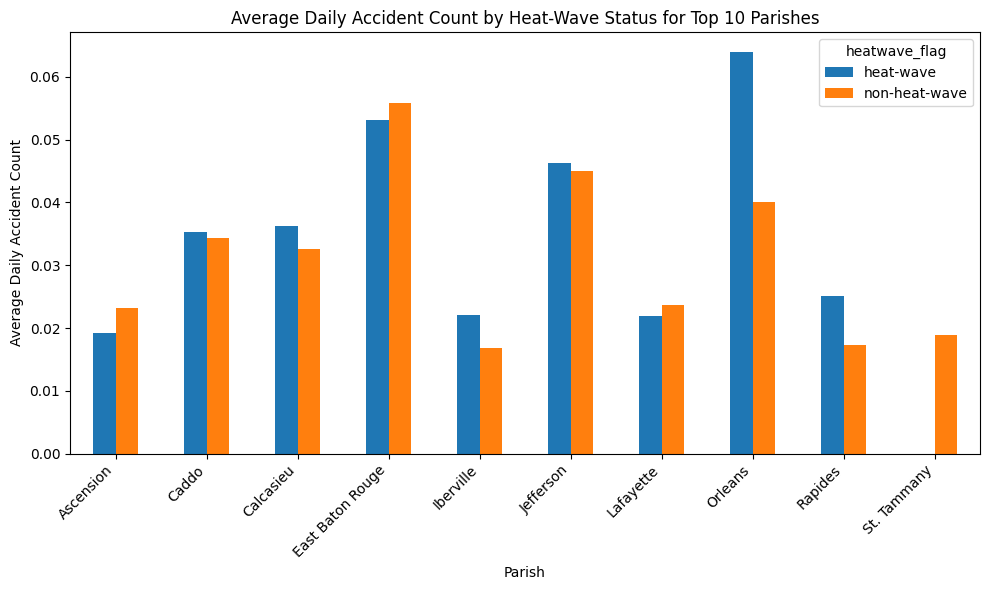

In [22]:
# Top Parishes by Accident Count

top_parishes = (
    merged.groupby("parish")["accident_count"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

plot_df = parish_summary[parish_summary["parish"].isin(top_parishes)]

import matplotlib.pyplot as plt

pivot_plot = plot_df.pivot(index="parish", columns="heatwave_flag", values="mean")
pivot_plot.plot(kind="bar", figsize=(10, 6))
plt.xlabel("Parish")
plt.ylabel("Average Daily Accident Count")
plt.title("Average Daily Accident Count by Heat-Wave Status for Top 10 Parishes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Industry-level Analysis

In [23]:
accident_detail["EventDate"] = pd.to_datetime(accident_detail["EventDate"], errors="coerce")
accident_detail["date"] = accident_detail["EventDate"].dt.normalize()

accident_detail[["parish", "date", "industry_type"]].head()

,parish,date,industry_type
0,East Baton Rouge,2023-06-15,Manufacturing
1,Terrebonne,2023-06-17,"Mining, Quarrying, and Oil and Gas Extraction"
2,Jefferson,2023-06-19,Utilities
3,De Soto,2023-06-20,Wholesale Trade
4,East Baton Rouge,2023-06-20,Retail Trade


In [24]:
industry_daily_counts = (
    accident_detail.groupby(["parish", "date", "industry_type"])
    .size()
    .reset_index(name="accident_count")
)

industry_daily_counts.head()

,parish,date,industry_type,accident_count
0,Acadia,2016-03-10,Manufacturing,1
1,Acadia,2016-09-13,Manufacturing,1
2,Acadia,2016-09-27,Utilities,1
3,Acadia,2017-05-10,Construction,1
4,Acadia,2017-11-07,Health Care and Social Assistance,1


In [25]:
industry_list = (
    accident_detail["industry_type"]
    .dropna()
    .sort_values()
    .unique()
)

weather_industry = weather.assign(key=1).merge(
    pd.DataFrame({"industry_type": industry_list, "key": 1}),
    on="key",
    how="left"
).drop(columns="key")

print(weather_industry.shape)
weather_industry.head()

(4814780, 25)


,parish,lcd_station_id,lcd_station_name,station_latitude,station_longitude,date,avg_temp,avg_dew_point,avg_relative_humidity,avg_wind_speed,...,avg_wind_speed_ms,vapor_pressure_hpa,avg_apparent_temp_c,min_apparent_temp_c,apparent_temp_85th_percentile,exceeds_threshold,run_id,run_length,heatwave_flag,industry_type
0,Acadia,WBAN:00381,"JENNINGS AIRPORT, LA US",30.243,-92.673,2015-01-01,6.770833,4.251389,84.444444,3.8,...,3.8,8.269414,2.83974,1.268907,28.893006,False,1,168,non-heat-wave,Accommodation and Food Services
1,Acadia,WBAN:00381,"JENNINGS AIRPORT, LA US",30.243,-92.673,2015-01-01,6.770833,4.251389,84.444444,3.8,...,3.8,8.269414,2.83974,1.268907,28.893006,False,1,168,non-heat-wave,Administrative and Support and Waste Managemen...
2,Acadia,WBAN:00381,"JENNINGS AIRPORT, LA US",30.243,-92.673,2015-01-01,6.770833,4.251389,84.444444,3.8,...,3.8,8.269414,2.83974,1.268907,28.893006,False,1,168,non-heat-wave,"Agriculture, Forestry, Fishing and Hunting"
3,Acadia,WBAN:00381,"JENNINGS AIRPORT, LA US",30.243,-92.673,2015-01-01,6.770833,4.251389,84.444444,3.8,...,3.8,8.269414,2.83974,1.268907,28.893006,False,1,168,non-heat-wave,"Arts, Entertainment, and Recreation"
4,Acadia,WBAN:00381,"JENNINGS AIRPORT, LA US",30.243,-92.673,2015-01-01,6.770833,4.251389,84.444444,3.8,...,3.8,8.269414,2.83974,1.268907,28.893006,False,1,168,non-heat-wave,Construction


In [26]:
industry_merged = weather_industry.merge(
    industry_daily_counts,
    on=["parish", "date", "industry_type"],
    how="left"
)

industry_merged["accident_count"] = industry_merged["accident_count"].fillna(0).astype(int)

print(industry_merged.shape)
industry_merged[["parish", "date", "industry_type", "heatwave_flag", "accident_count"]].head()

(4814780, 26)


,parish,date,industry_type,heatwave_flag,accident_count
0,Acadia,2015-01-01,Accommodation and Food Services,non-heat-wave,0
1,Acadia,2015-01-01,Administrative and Support and Waste Managemen...,non-heat-wave,0
2,Acadia,2015-01-01,"Agriculture, Forestry, Fishing and Hunting",non-heat-wave,0
3,Acadia,2015-01-01,"Arts, Entertainment, and Recreation",non-heat-wave,0
4,Acadia,2015-01-01,Construction,non-heat-wave,0


In [27]:
industry_state_summary = (
    industry_merged.groupby(["industry_type", "heatwave_flag"])["accident_count"]
    .agg(["mean", "std", "sum", "count"])
    .reset_index()
)

industry_state_summary.head(20)

,industry_type,heatwave_flag,mean,std,sum,count
0,Accommodation and Food Services,heat-wave,0.000206,0.014338,3,14591
1,Accommodation and Food Services,non-heat-wave,0.000106,0.010301,24,226148
2,Administrative and Support and Waste Managemen...,heat-wave,0.000548,0.023410,8,14591
3,Administrative and Support and Waste Managemen...,non-heat-wave,0.000597,0.024425,135,226148
4,"Agriculture, Forestry, Fishing and Hunting",heat-wave,0.000069,0.008279,1,14591
5,"Agriculture, Forestry, Fishing and Hunting",non-heat-wave,0.000177,0.013298,40,226148
6,"Arts, Entertainment, and Recreation",heat-wave,0.000000,0.000000,0,14591
7,"Arts, Entertainment, and Recreation",non-heat-wave,0.000080,0.008921,18,226148
8,Construction,heat-wave,0.002604,0.050968,38,14591
9,Construction,non-heat-wave,0.001738,0.041651,393,226148


In [28]:
industry_compare = industry_state_summary.pivot(
    index="industry_type",
    columns="heatwave_flag",
    values=["mean", "std", "sum", "count"]
)

industry_compare.columns = [
    f"{stat}_{flag}" for stat, flag in industry_compare.columns
]
industry_compare = industry_compare.reset_index()

industry_compare.head()

,industry_type,mean_heat-wave,mean_non-heat-wave,std_heat-wave,std_non-heat-wave,sum_heat-wave,sum_non-heat-wave,count_heat-wave,count_non-heat-wave
0,Accommodation and Food Services,0.000206,0.000106,0.014338,0.010301,3.0,24.0,14591.0,226148.0
1,Administrative and Support and Waste Managemen...,0.000548,0.000597,0.023410,0.024425,8.0,135.0,14591.0,226148.0
2,"Agriculture, Forestry, Fishing and Hunting",0.000069,0.000177,0.008279,0.013298,1.0,40.0,14591.0,226148.0
3,"Arts, Entertainment, and Recreation",0.000000,0.000080,0.000000,0.008921,0.0,18.0,14591.0,226148.0
4,Construction,0.002604,0.001738,0.050968,0.041651,38.0,393.0,14591.0,226148.0


In [29]:
industry_compare["percent_change_mean"] = (
    (industry_compare["mean_heat-wave"] - industry_compare["mean_non-heat-wave"])
    / industry_compare["mean_non-heat-wave"]
) * 100

industry_compare["percent_change_mean"] = industry_compare["percent_change_mean"].replace(
    [float("inf"), float("-inf")], pd.NA
)

industry_compare.sort_values("percent_change_mean", ascending=False).head(15)

,industry_type,mean_heat-wave,mean_non-heat-wave,std_heat-wave,std_non-heat-wave,sum_heat-wave,sum_non-heat-wave,count_heat-wave,count_non-heat-wave,percent_change_mean
6,Finance and Insurance,0.000069,0.000022,0.008279,0.004702,1.0,5.0,14591.0,226148.0,209.982866
18,Utilities,0.000343,0.000133,0.018509,0.011517,5.0,30.0,14591.0,226148.0,158.319055
8,Information,0.000343,0.000146,0.018509,0.012079,5.0,33.0,14591.0,226148.0,134.835505
12,"Professional, Scientific, and Technical Services",0.000411,0.000208,0.020275,0.014415,6.0,47.0,14591.0,226148.0,97.861404
0,Accommodation and Food Services,0.000206,0.000106,0.014338,0.010301,3.0,24.0,14591.0,226148.0,93.739291
7,Health Care and Social Assistance,0.000480,0.000261,0.021899,0.016150,7.0,59.0,14591.0,226148.0,83.888141
13,Public Administration,0.000137,0.000080,0.011707,0.008921,2.0,18.0,14591.0,226148.0,72.212703
4,Construction,0.002604,0.001738,0.050968,0.041651,38.0,393.0,14591.0,226148.0,49.864490
15,Retail Trade,0.000959,0.000641,0.030962,0.025313,14.0,145.0,14591.0,226148.0,49.646901
10,"Mining, Quarrying, and Oil and Gas Extraction",0.000754,0.000601,0.027448,0.024874,11.0,136.0,14591.0,226148.0,25.360718


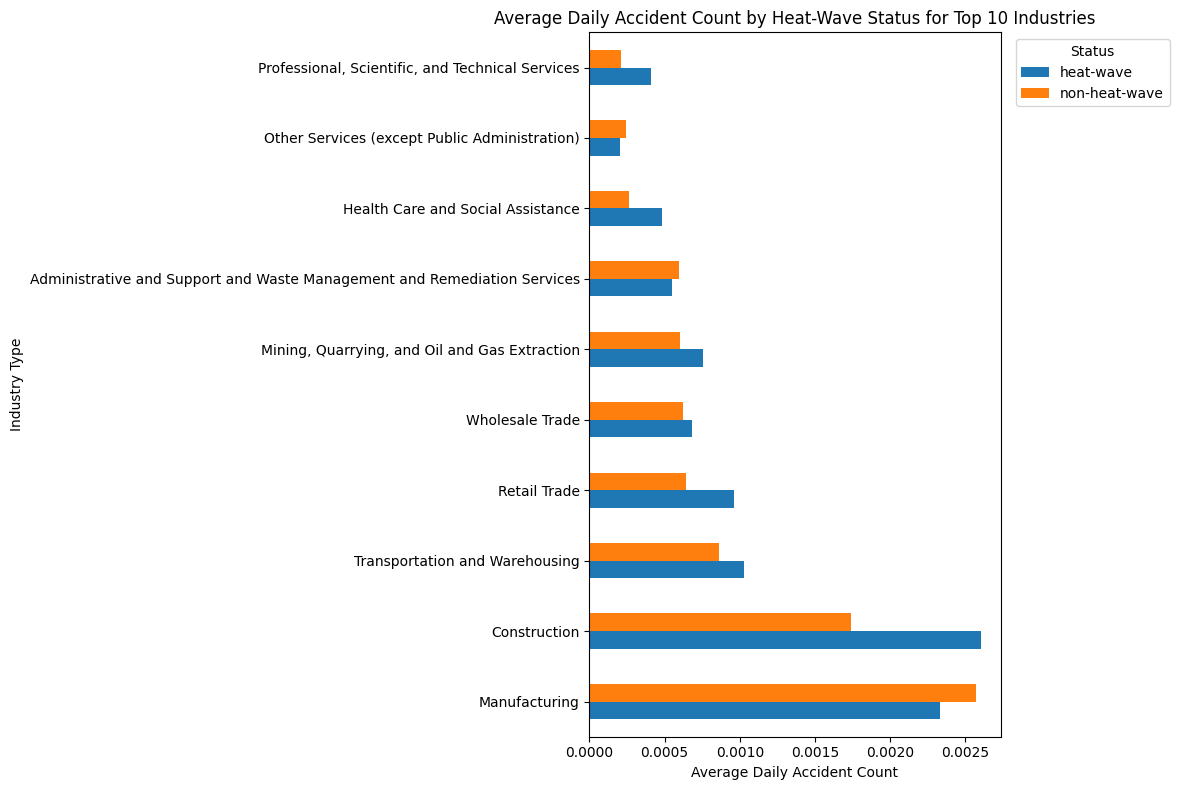

In [30]:
top_industries = (
    industry_merged.groupby("industry_type")["accident_count"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

plot_df = industry_state_summary[
    industry_state_summary["industry_type"].isin(top_industries)
]

pivot_plot = (
    plot_df.pivot(index="industry_type", columns="heatwave_flag", values="mean")
    .loc[top_industries]
)

pivot_plot.plot(kind="barh", figsize=(12, 8))
plt.xlabel("Average Daily Accident Count")
plt.ylabel("Industry Type")
plt.title("Average Daily Accident Count by Heat-Wave Status for Top 10 Industries")
plt.legend(title="Status", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()